# Exercise 12 - Batch Gradient Descent and Softmax regression on Iris Dataset

In [12]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [2]:
iris = datasets.load_iris()

X = iris["data"][:, (2, 3)]   # petal length, petal width
y = iris["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", iris["target_names"])

X shape: (150, 2)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
X_with_bias = np.c_[np.ones((len(X), 1)), X]
print("X with bias shape:", X_with_bias.shape)

X with bias shape: (150, 3)


In [5]:
np.random.seed(2042)

test_ratio = 0.2
validation_ratio = 0.2

total_size = len(X_with_bias)
test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

random_indices = np.random.permutation(total_size)

train_indices = random_indices[:train_size]
validation_indices = random_indices[train_size:train_size + validation_size]
test_indices = random_indices[train_size + validation_size:]

X_train = X_with_bias[train_indices]
y_train = y[train_indices]

X_valid = X_with_bias[validation_indices]
y_valid = y[validation_indices]

X_test = X_with_bias[test_indices]
y_test = y[test_indices]

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Training: (90, 3)
Validation: (30, 3)
Test: (30, 3)


In [6]:
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)

X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

print("Training feature means:", X_train[:, 1:].mean(axis=0))
print("Training feature stds:", X_train[:, 1:].std(axis=0))

Training feature means: [2.83723662e-16 1.23358114e-16]
Training feature stds: [1. 1.]


In [7]:
n_classes = len(np.unique(y))
Y_train = np.eye(n_classes)[y_train]
Y_valid = np.eye(n_classes)[y_valid]
Y_test = np.eye(n_classes)[y_test]

print(Y_train[:5])

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [10]:
def softmax(logits):
    exp = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_proba):
    epsilon = 1e-7
    y_proba = np.clip(y_proba, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_proba), axis=1))

n_features = X_train.shape[1]
theta = np.random.randn(n_features, n_classes)
print("theta (logits = X.theta) shape:", theta.shape)

theta (logits = X.theta) shape: (3, 3)


In [11]:
learning_rate = 0.5
n_epochs = 5001

best_loss = np.inf
best_theta = None
patience = 100
patience_counter = 0

train_losses = []
valid_losses = []
for epoch in range(n_epochs):
    logits = X_train @ theta
    y_proba = softmax(logits)
    train_loss = cross_entropy_loss(Y_train, y_proba)

    valid_logits = X_valid @ theta
    valid_proba = softmax(valid_logits)
    valid_loss = cross_entropy_loss(Y_valid, valid_proba)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    gradients = (X_train.T @ (y_proba - Y_train)) / len(X_train)
    theta -= learning_rate * gradients

    if valid_loss < best_loss:
        best_loss = valid_loss
        best_theta = theta.copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | "f"Training loss: {train_loss:.4f} | "f"Validation loss: {valid_loss:.4f}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

theta = best_theta

Epoch    0 | Training loss: 1.8190 | Validation loss: 1.6810
Epoch  500 | Training loss: 0.0951 | Validation loss: 0.1112
Epoch 1000 | Training loss: 0.0784 | Validation loss: 0.0912
Epoch 1500 | Training loss: 0.0718 | Validation loss: 0.0823
Epoch 2000 | Training loss: 0.0684 | Validation loss: 0.0769
Epoch 2500 | Training loss: 0.0662 | Validation loss: 0.0733
Epoch 3000 | Training loss: 0.0648 | Validation loss: 0.0707
Epoch 3500 | Training loss: 0.0638 | Validation loss: 0.0686
Epoch 4000 | Training loss: 0.0631 | Validation loss: 0.0670
Epoch 4500 | Training loss: 0.0626 | Validation loss: 0.0658
Epoch 5000 | Training loss: 0.0622 | Validation loss: 0.0647


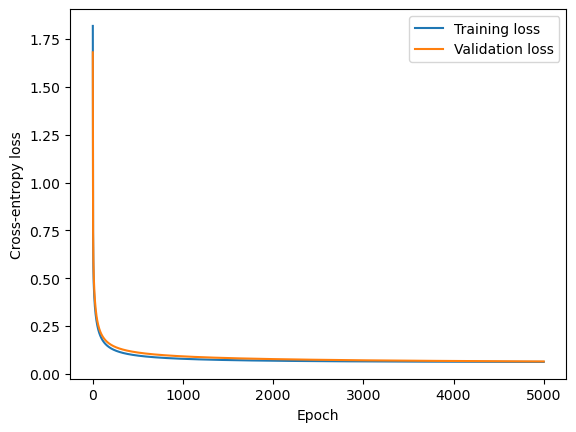

In [13]:
plt.plot(train_losses, label="Training loss")
plt.plot(valid_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

In [15]:
def predict(X, theta):
    probabilities = softmax(X @ theta)
    return np.argmax(probabilities, axis=1)

y_train_pred = predict(X_train, theta)
y_valid_pred = predict(X_valid, theta)
y_test_pred = predict(X_test, theta)

train_accuracy = np.mean(y_train_pred == y_train)
valid_accuracy = np.mean(y_valid_pred == y_valid)
test_accuracy = np.mean(y_test_pred == y_test)

print("Training accuracy:  ", train_accuracy)
print("Validation accuracy:", valid_accuracy)
print("Test accuracy:      ", test_accuracy)

Training accuracy:   0.9666666666666667
Validation accuracy: 0.9666666666666667
Test accuracy:       0.9333333333333333


In [16]:
test_probabilities = softmax(X_test @ theta)

print("Predicted probabilities:")
print(test_probabilities[:10])

print("\nPredicted classes:")
print(y_test_pred[:10])

print("\nActual classes:")
print(y_test[:10])

Predicted probabilities:
[[3.17791036e-07 1.62390531e-01 8.37609152e-01]
 [1.61734047e-11 3.96028243e-04 9.99603972e-01]
 [3.87010182e-13 3.49711325e-05 9.99965029e-01]
 [1.58104336e-02 9.84185699e-01 3.86730237e-06]
 [7.32969002e-04 9.98819385e-01 4.47646467e-04]
 [7.28528105e-03 9.92697983e-01 1.67360205e-05]
 [9.99443480e-01 5.56519667e-04 1.29812154e-17]
 [9.99443480e-01 5.56519667e-04 1.29812154e-17]
 [9.99571330e-01 4.28670451e-04 6.15352159e-18]
 [2.02564885e-09 6.43977746e-03 9.93560221e-01]]

Predicted classes:
[2 2 2 1 1 1 0 0 0 2]

Actual classes:
[1 2 2 1 1 1 0 0 0 2]


In [17]:
print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"Best validation loss: {best_loss:.4f}")
print(f"Training accuracy:    {train_accuracy:.4f}")
print(f"Validation accuracy:  {valid_accuracy:.4f}")
print(f"Test accuracy:        {test_accuracy:.4f}")

FINAL RESULTS
Best validation loss: 0.0647
Training accuracy:    0.9667
Validation accuracy:  0.9667
Test accuracy:        0.9333


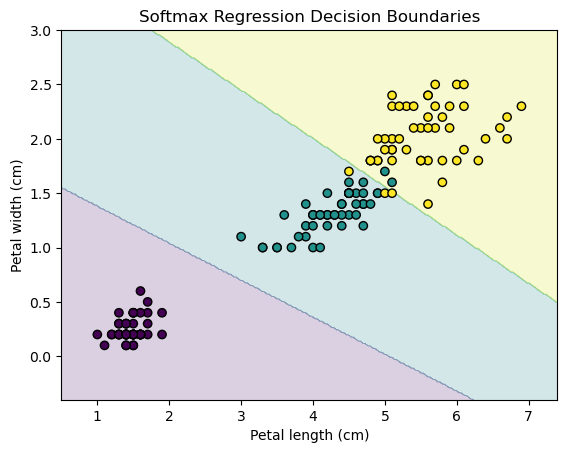

In [18]:
x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300), np.linspace(x1_min, x1_max, 300))
grid = np.c_[np.ones(xx0.ravel().shape), (xx0.ravel() - mean[0]) / std[0], (xx1.ravel() - mean[1]) / std[1]]
Z = predict(grid, theta).reshape(xx0.shape)

plt.contourf(xx0, xx1, Z, alpha=0.2)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Softmax Regression Decision Boundaries")
plt.show()

The manual implementation of softmax regression with gradient descent perform well on the train and test set indicating good generalization performance. We get very high accuracy also due the the almost linearly separable nature of the dataset.